<a href="https://colab.research.google.com/github/mayait/CursoAnalisisDatos_IA_2026/blob/main/sitio/labs/taller_05_superstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Taller 5 · La trampa del promedio

Este cuaderno es la versión en Python del taller de D2L: el mismo caso, ahora con el código en tus manos. Los datos: **Superstore**, una cadena minorista de Estados Unidos con cuatro años de ventas (septiembre 2022 – agosto 2026): 9,994 líneas de venta que forman 5,009 pedidos. Tu papel: es tu **primer día como analista** y María, la gerente regional Oeste, te hizo tres preguntas "fáciles". Las tres se responden con un promedio. Las tres decisiones salen mal si respondes solo con el promedio.

> **Hoy haces** · Un caso en tres actos con regla de casino: **se apuesta antes de calcular**. Tres preguntas de la gerente, tres trampas, y al final tu caja de herramientas de estadística descriptiva (~50 min en clase; se termina en casa).
>
> **Entrega** · El cuaderno ejecutado de principio a fin, con tus tres apuestas registradas, el ejercicio guiado, el desafío y el memo final. Nombre: `taller_05_apellido.ipynb`, al buzón de D2L antes del miércoles.

In [1]:
# --- Setup del entorno ---
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("Setup completo ✓")
print(f"pandas {pd.__version__} · numpy {np.__version__}")

Setup completo ✓
pandas 2.3.3 · numpy 2.2.6


## El caso · Lunes, 8h07

Primer día. Todavía no encuentras la cafetera y ya tienes tres mensajes de María, la gerente regional Oeste:

> **[8h02] María** — ¡Bienvenido/a al equipo! Para el comité de las 10h00 necesito tres números:
>
> 1. Voy a lanzar **«envío gratis desde $X»** y no sé a qué precio poner la X: ¿cuánto vale un **pedido típico**?
> 2. Entre **Muebles** y **Suministros de Oficina**, ¿qué categoría es más rentable por venta? Quiero duplicar el inventario de la ganadora.
> 3. Auditoría dice que hay que **eliminar Libreros** porque pierde plata. ¿Confirmas?
>
> Nada elegante: un número por pregunta. ¡Gracias!

Tres preguntas del escalón 1 de la escalera —descriptivas, *¿qué pasó?*— y sin embargo cada una puede inducir una decisión equivocada. Ese es el punto de hoy: **la primera etapa del análisis es la que más rigor merece, porque es la que todos creen fácil.**

### La regla del taller

**Se apuesta antes de calcular.** Cada acto abre con una celda `✍️ APUESTA` donde anotas tu número antes de ejecutar el código. Nadie califica la puntería; se califica que apuestes. Una predicción equivocada abre el hueco que la explicación llena: así se aprende.

In [2]:
URL = ("https://raw.githubusercontent.com/mayait/"
       "CursoAnalisisDatos_IA_2026/main/sitio/datos/superstore_2026.csv")
df = pd.read_csv(URL, parse_dates=["fecha_pedido", "fecha_envio"])
print(f"{df.shape[0]:,} líneas de venta · {df['pedido_id'].nunique():,} pedidos")
print(f"del {df['fecha_pedido'].min():%d-%b-%Y} al {df['fecha_pedido'].max():%d-%b-%Y}")
df.head(3)

9,994 líneas de venta · 5,009 pedidos
del 02-Sep-2022 al 29-Aug-2026


,linea_id,pedido_id,fecha_pedido,fecha_envio,modo_envio,cliente_id,cliente,segmento,pais,ciudad,estado,codigo_postal,region,producto_id,categoria,subcategoria,producto,venta,cantidad,descuento,utilidad
0,1,CA-2025-152156,2025-07-08,2025-07-11,Segunda clase,CG-12520,Claire Gute,Consumidor,Estados Unidos,Henderson,Kentucky,42420,Sur,FUR-BO-10001798,Muebles,Libreros,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2025-152156,2025-07-08,2025-07-11,Segunda clase,CG-12520,Claire Gute,Consumidor,Estados Unidos,Henderson,Kentucky,42420,Sur,FUR-CH-10000454,Muebles,Sillas,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2025-138688,2025-02-09,2025-02-13,Segunda clase,DV-13045,Darrin Van Huff,Corporativo,Estados Unidos,Los Angeles,California,90036,Oeste,OFF-LA-10000240,Suministros de Oficina,Etiquetas,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87


Cada fila es una **línea de venta**: un producto dentro de un pedido. Las columnas de hoy:

| Columna | Qué es |
|---|---|
| `pedido_id` | El pedido al que pertenece la línea (un pedido junta 2 líneas en promedio) |
| `categoria` → `subcategoria` → `producto` | Muebles, Suministros de Oficina o Tecnología, y sus 17 subcategorías |
| `venta` | Ingreso de la línea en USD, ya con el descuento aplicado |
| `descuento` | Fracción descontada (0 = sin descuento, 0.7 = 70 %) |
| `utilidad` | Ganancia de la línea en USD (negativa = pérdida) |

⚠️ **La lección de la semana 2 aplica desde ya**: "¿cuánto vale un pedido típico?" pregunta por **pedidos**, y esta tabla trae **líneas**. Calcular sobre la tabla sin agrupar es responder otra pregunta.

## Acto 1 · ¿Cuánto vale un pedido típico?

María presupuestará las comisiones de 2027 multiplicando *pedidos esperados × valor del pedido típico*. Si ese número está inflado, el presupuesto nace roto.

### ✍️ APUESTA 1

Sin calcular nada: ¿cuántos dólares vale un pedido típico? Y si calculas el promedio, ¿qué porcentaje de los pedidos crees que queda **por debajo** de él? (En un mundo simétrico sería más o menos la mitad...)

In [3]:
# Escribe tus apuestas ANTES de seguir (números, sin comillas)
mi_pedido_tipico = None        # ej: 350
mi_pct_bajo_promedio = None    # ej: 50   (por ciento)

Primero, la unidad correcta: de líneas a pedidos. `groupby` colapsa las 9,994 líneas en sus 5,009 pedidos y `sum` junta las líneas de cada uno.

In [4]:
pedidos = df.groupby("pedido_id")["venta"].sum()
media = pedidos.mean()
print(f"Pedidos: {len(pedidos):,}")
print(f"El pedido PROMEDIO vale: ${media:,.2f}")

Pedidos: 5,009
El pedido PROMEDIO vale: $458.61


$459. ¿Se lo mandas a María y pasas a lo siguiente? Espera: pídele a los mismos datos el otro número de centro, el del pedido que queda justo **en la mitad de la fila** cuando los ordenas todos.

In [5]:
mediana = pedidos.median()
pct_bajo = (pedidos < media).mean() * 100
print(f"Pedido mediano:  ${mediana:,.2f}")
print(f"Pedido promedio: ${media:,.2f}   ({media/mediana:.1f} veces la mediana)")
print(f"Pedidos por debajo del promedio: {pct_bajo:.1f}%")
if mi_pct_bajo_promedio is not None:
    print(f"Tu apuesta: {mi_pct_bajo_promedio}% → te alejaste "
          f"{abs(pct_bajo - mi_pct_bajo_promedio):.1f} puntos")

Pedido mediano:  $151.96
Pedido promedio: $458.61   (3.0 veces la mediana)
Pedidos por debajo del promedio: 72.5%


#### ⚠️ La trampa: la cola larga

El promedio ($459) vale **3 veces** la mediana ($152), y **el 72.5 % de los pedidos queda por debajo del promedio**. Ese promedio no describe al pedido típico: describe la mezcla de miles de pedidos chicos con unos pocos monstruos.

El monstruo mayor es el pedido `CA-2022-145317`: **$23,661**, casi todo un equipo de videoconferencia Cisco de $22,638. Ese solo pedido arrastra el promedio hacia arriba; a la mediana ni la despeina, porque la mediana solo cuenta *cuántos* pedidos quedan a cada lado, no *cuánto pesan*.

#### 💡 Un histograma vale más que dos promedios

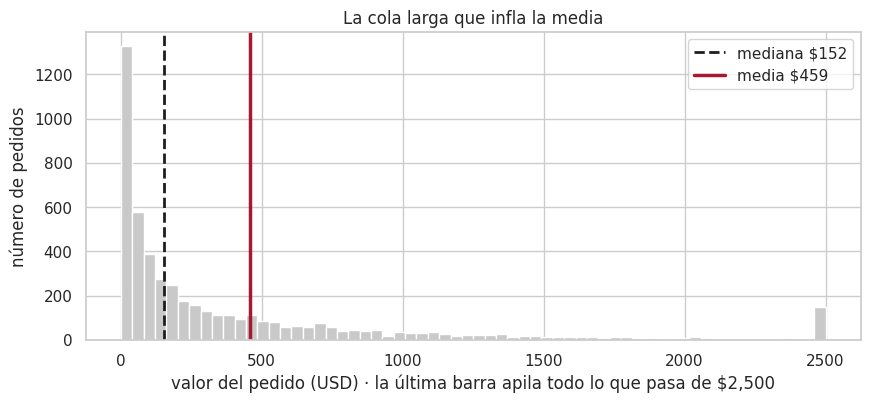

In [6]:
fig, ax = plt.subplots()
ax.hist(pedidos.clip(upper=2500), bins=62, color="#c9c9c9", edgecolor="white")
ax.axvline(mediana, color="#1e1e1e", ls="--", lw=2, label=f"mediana ${mediana:,.0f}")
ax.axvline(media, color="#A6192E", lw=2.5, label=f"media ${media:,.0f}")
ax.set_xlabel("valor del pedido (USD) · la última barra apila todo lo que pasa de $2,500")
ax.set_ylabel("número de pedidos")
ax.set_title("La cola larga que infla la media")
ax.legend()
plt.show()

In [7]:
# Los percentiles cuentan la historia completa en seis números
print(pedidos.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(0).to_string())
print(f"máximo: ${pedidos.max():,.0f}")

0.10      13.00
0.25      38.00
0.50     152.00
0.75     512.00
0.90   1,154.00
0.99   4,209.00
máximo: $23,661


#### 🎯 La decisión

Si María ancla el umbral en el promedio ($459), lo pone donde el 72.5 % de los pedidos ni llega: promoción muerta. Anclando en la mediana ($152), un umbral de ≈$200 (entre p50 y p75) deja a la mitad de los pedidos a un empujón. La respuesta profesional no es un número, son dos y una advertencia.

**✍️ TU RESPUESTA** *(edita esta celda)* — ¿Qué número le mandas a María y con qué advertencia de una línea?

> Escribe aquí...

## Acto 2 · La categoría "estrella"

Segunda pregunta: entre **Muebles** y **Suministros de Oficina**, ¿cuál deja más utilidad por línea de venta? La ganadora duplica inventario.

### ✍️ APUESTA 2

¿Cuál gana? ¿Y por cuánto: pelea pareja o paliza?

In [8]:
mi_categoria_ganadora = "..."   # "Muebles" o "Suministros de Oficina"

In [9]:
duelo = df[df["categoria"].isin(["Muebles", "Suministros de Oficina"])]
duelo.groupby("categoria")["utilidad"].mean().round(2)

categoria
Muebles                   8.70
Suministros de Oficina   20.33
Name: utilidad, dtype: float64

Paliza: Suministros de Oficina gana **$20.33 contra $8.70**, 2.3 a 1. Caso cerrado... si no fuera lunes y no hubieras visto el Acto 1. Repite el duelo con la mediana:

In [10]:
duelo.groupby("categoria")["utilidad"].agg(["mean", "median", "count"]).round(2)

,mean,median,count
categoria,,,
Muebles,8.70,7.77,2121
Suministros de Oficina,20.33,6.88,6026


**El duelo se voltea**: por mediana gana Muebles, $7.77 contra $6.88. La línea *típica* de Muebles deja más utilidad que la línea típica de Suministros de Oficina. ¿Entonces quién le infla la media a Suministros? Búscalo:

In [11]:
sdo = df[df["categoria"] == "Suministros de Oficina"]
sdo.nlargest(5, "utilidad")[["subcategoria", "producto", "utilidad"]]

,subcategoria,producto,utilidad
9039,Carpetas,GBC Ibimaster 500 Manual ProClick Binding System,"4,946.37"
4098,Carpetas,Ibico EPK-21 Electric Binding System,"4,630.48"
509,Carpetas,Fellowes PB500 Electric Punch Plastic Comb Bin...,"3,177.47"
6520,Carpetas,GBC DocuBind P400 Electric Binding System,"2,504.22"
7683,Carpetas,Fellowes PB500 Electric Punch Plastic Comb Bin...,"1,906.48"


#### ⚠️ La trampa: los extremos mandan sobre la media

Las cinco líneas más rentables de Suministros de Oficina son **encuadernadoras industriales** de la subcategoría Carpetas: una GBC con $4,946 de utilidad, una Ibico con $4,630... Si quitas las 20 mejores líneas —el 0.3 % de las 6,026— la media cae de $20.33 a **$14.61**. La "superioridad" de toda la categoría cuelga de un puñado de ventas.

Y la trampa es fractal: dentro de Carpetas, media $19.84 contra mediana **$3.98**. El mismo patrón, un piso más abajo.

#### 🎯 La decisión

"Duplicar Suministros de Oficina" por su media es duplicar papel, sobres y material de arte esperando que se comporten como encuadernadoras de $5,000. La pregunta correcta para María no es qué *categoría* duplicar sino qué *productos*, y eso lo responde el perfilado del miércoles.

## Acto 3 · La trampa inversa

Tercera pregunta. El memo de auditoría dice, textual:

> *"La subcategoría **Libreros** acumuló una pérdida neta de $3,473 en cuatro años, con una utilidad media de −$15.23 por línea. Recomendación: descontinuarla."*

Las dos cifras son correctas. Y tú ya viste dos veces que la media engaña y que la mediana rescata...

### ✍️ APUESTA 3

La venta *típica* de Libreros —su mediana—, ¿gana o pierde plata? Y sabiendo eso, ¿firmarías el memo?

In [12]:
mi_apuesta_libreros = "..."   # "gana" o "pierde"

In [13]:
libreros = df.loc[df["subcategoria"] == "Libreros", "utilidad"]
print(f"Líneas de venta: {len(libreros)}")
print(f"Mediana: ${libreros.median():+,.2f}   ← la venta típica GANA plata")
print(f"Media:   ${libreros.mean():+,.2f}")
print(f"Total:   ${libreros.sum():+,.0f}")

Líneas de venta: 228
Mediana: $+4.13   ← la venta típica GANA plata
Media:   $-15.23
Total:   $-3,473


#### ⚠️ Esta vez la que engaña es la mediana

La venta típica de Libreros gana $4.13... y la subcategoría entera pierde $3,473. Si defendías Libreros "porque la mediana es positiva", caíste en la trampa opuesta a la de María. La mediana ignora los tamaños: no ve que las pérdidas, cuando llegan, llegan enormes.

Ninguna medida de centro basta sola. Mira la distribución:

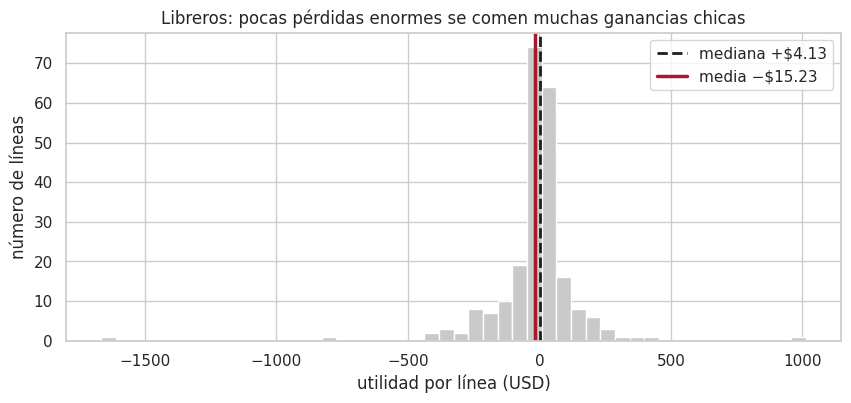

34 líneas pierden más de $100 cada una; entre todas suman $-9,506


In [14]:
fig, ax = plt.subplots()
ax.hist(libreros, bins=48, color="#c9c9c9", edgecolor="white")
ax.axvline(libreros.median(), color="#1e1e1e", ls="--", lw=2,
           label=f"mediana +${libreros.median():.2f}")
ax.axvline(libreros.mean(), color="#A6192E", lw=2.5,
           label=f"media −${abs(libreros.mean()):.2f}")
ax.set_xlabel("utilidad por línea (USD)")
ax.set_ylabel("número de líneas")
ax.set_title("Libreros: pocas pérdidas enormes se comen muchas ganancias chicas")
ax.legend()
plt.show()

grandes_perdidas = libreros[libreros < -100]
print(f"{len(grandes_perdidas)} líneas pierden más de $100 cada una; "
      f"entre todas suman ${grandes_perdidas.sum():,.0f}")

34 líneas de 228 —una de cada siete— pierden más de $100, y entre todas se comen $9,506: casi el triple de la pérdida total. ¿Qué tienen en común? Sube un escalón de la escalera y pregunta **por qué**:

In [15]:
(df[df["subcategoria"] == "Libreros"]
   .groupby("descuento")["utilidad"]
   .agg(["count", "mean"])
   .round(1))

,count,mean
descuento,,
0.00,60,101.30
0.15,52,27.30
0.20,46,2.80
0.30,10,-55.60
0.32,27,-88.60
0.50,18,-236.40
0.70,15,-259.70


#### 🎯 La decisión

Sin descuento, Libreros gana **$101 por línea**. Con descuentos del 50 % o 70 % pierde **entre $236 y $260 por línea**. El problema no es el mueble: es la política de descuentos. El memo correcto no dice "descontinuar Libreros"; dice "revisar quién autoriza descuentos del 50 % en Libreros".

📌 Fíjate lo que acaba de pasar: la pregunta *¿qué pasó?* (descriptiva) te empujó sola hacia *¿por qué pasó?* (diagnóstica). Así se sube la escalera: no por ambición, por necesidad.

## Bonus · El patrón se repite donde mires

Las 5,196 líneas vendidas **con descuento**: media **−$6.66** (pierde), mediana **+$3.34** (gana). Dos historias opuestas sobre las mismas filas; ya sabes que eso huele a dos poblaciones mezcladas en una sola distribución. Compruébalo tú en el desafío si te sobra energía.

## La caja de herramientas descriptiva

Lo que hiciste a mano en tres actos tiene nombre, y una línea de pandas cada uno:

| Pregunta | Estadístico | pandas |
|---|---|---|
| ¿Alrededor de qué valor caen los datos? | media, mediana, moda | `.mean()` · `.median()` · `.mode()` |
| ¿Qué valor deja debajo al X %? | percentiles | `.quantile(0.90)` |
| ¿Qué tan repartidos están? | desviación estándar, IQR, coef. de variación | `.std()` · `Q3 − Q1` · `std/mean` |
| ¿Cuántos hay de cada tipo? | frecuencias | `.value_counts()` |
| Todo lo anterior de un golpe | perfilado | `.describe()` |

**La regla de la casa**: media para distribuciones simétricas y sin extremos; mediana cuando hay colas o extremos; moda para categorías... y **ninguna sin haber visto el histograma**. Quien reporta un centro sin mirar la distribución no está resumiendo: está adivinando.

In [16]:
moda = df["venta"].mode()[0]
print(f"Moda de venta por línea: ${moda}  "
      f"(se repite {(df['venta'] == moda).sum()} veces; casi siempre resmas de papel Xerox)")
print(f"Desviación estándar del pedido: ${pedidos.std():,.0f}")
print(f"Coeficiente de variación: {pedidos.std() / pedidos.mean():.2f}"
      "  → ¡la desviación duplica a la media!")
q1, q3 = pedidos.quantile([0.25, 0.75])
print(f"Rango intercuartílico: ${q3 - q1:,.0f}  "
      f"(el 50 % central de los pedidos vive entre ${q1:,.0f} y ${q3:,.0f})")
print()
print("Pedidos por segmento (proporción):")
print(df.groupby("pedido_id")["segmento"].first().value_counts(normalize=True).round(3).to_string())

Moda de venta por línea: $12.96  (se repite 56 veces; casi siempre resmas de papel Xerox)
Desviación estándar del pedido: $955
Coeficiente de variación: 2.08  → ¡la desviación duplica a la media!
Rango intercuartílico: $474  (el 50 % central de los pedidos vive entre $38 y $512)

Pedidos por segmento (proporción):
segmento
Consumidor        0.52
Corporativo       0.30
Oficina en casa   0.18


## Ejercicios

### 🌶️ Ejercicio 1 — Guiado · El segmento de oro

Marketing quiere invertir donde está "el cliente que más gasta por pedido". Hay tres segmentos: Consumidor, Corporativo y Oficina en casa.

1. Construye una tabla por pedido con su venta total y su segmento. Pista: `df.groupby("pedido_id").agg(venta=("venta", "sum"), segmento=("segmento", "first"))`.
2. Calcula media y mediana del valor de pedido por segmento.
3. Responde en un comentario: ¿qué segmento gana por media? ¿Y por mediana? ¿Le cambia la decisión a marketing?

In [17]:
# TU CÓDIGO AQUÍ
# Paso 1: pedidos_seg = ...
# Paso 2: pedidos_seg.groupby("segmento")["venta"].agg(["mean", "median", "count"])
# Paso 3 (comentario): ...

### 🔥 Desafío extra · El verdadero agujero de Muebles

Auditoría, dolida por lo de Libreros, contraataca: *"en Muebles hay una subcategoría que pierde plata se mire como se mire: media negativa, mediana negativa y total negativo"*. Encuéntrala, saca las tres cifras y escribe una línea: ¿en qué se diferencia su caso del de Libreros? Si te sobra energía, verifica también el Bonus: haz el histograma de `utilidad` de las líneas con descuento y busca las dos jorobas.

In [18]:
# TU CÓDIGO AQUÍ

### 🎯 Reto en clase (15 min) · El memo de las 10h00

Son las 9h45. Responde el mensaje de María en **máximo tres líneas, un número por pregunta, cada uno con su advertencia**. Sin jerga: María no sabe qué es una mediana ni tiene por qué saberlo; traduce a su idioma ("el pedido típico", "la mitad de los pedidos", "unas pocas ventas gigantes").

**✍️ TU MEMO** *(edita esta celda)*

> **Para:** María · **Asunto:** Tus tres números para el comité
>
> 1. ...
> 2. ...
> 3. ...

## Checkpoint y entrega

Antes de subir el cuaderno, verifica:

- [ ] Corre de principio a fin sin errores (`Entorno de ejecución → Ejecutar todo`).
- [ ] Tus tres apuestas quedaron escritas (perderlas vale más que borrarlas).
- [ ] Ejercicio guiado, desafío y memo respondidos.
- [ ] Si usaste el asistente de IA, pega al final el prompt que usaste y qué verificaste de su respuesta.

**Entrega** · `taller_05_apellido.ipynb` al buzón de D2L antes del miércoles.

**Para tu equipo** · Corran la pregunta del Acto 1 sobre el dataset de su caso: ¿la media y la mediana de su variable de dinero cuentan la misma historia? Traigan el histograma: el miércoles abrimos la clase con dos de ellos.

**El miércoles** · Perfilado descriptivo contra reloj sobre Comercial Andina: `describe`, `quantile`, `value_counts` y doce preguntas de negocio cronometradas. Hoy fue la trampa; el miércoles, la velocidad.